In [2]:
import json
import re
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

EVAL_DIR = Path("/data/checkpoints/mcp/eval_results")

# Trained models to plot. Each: model_prefix -> (display_name, base_ckpt_name, color)
TRAINED_MODELS = {
    "qwen3-4B-Instruct-2507-4b-train-hf": ("Qwen3-4B (finetuned)", "Qwen__Qwen3-4B-Thinking-2507", "#2980B9"),
    "qwen3-30B-A3B-30b-train-hf": ("Qwen3-30B-A3B (finetuned)", "Qwen__Qwen3-30B-A3B-Thinking-2507", "#27AE60"),
    "qwen3-30B-A3B-30b-train-fix-multiturn-rollout-expert-hf": (
        "Qwen3-30B-A3B (fix multi-turn routing)",
        "Qwen__Qwen3-30B-A3B-Thinking-2507",
        "#D35400",
    ),
    # qwen3.6-27B (dense, flashqla GDN). No base-model eval available, so base_ckpt
    # name is left empty -> curve starts at the first trained iter (handled below).
    # NOTE: this run was evaluated with --passes 4, so it only has pass@1..4; it will
    # be absent (NaN gap) from the pass@8 / pass@16 subplots rather than plotted as 0.
    "qwen3.6-27B-test-cp-flashqla-hf": (
        "Qwen3.6-27B (flashqla)",
        "",
        "#E91E63",
    ),
    "qwen3-30B-A3B-insc-test-hf": (
        "Qwen3-30B-A3B (insc-test)",
        "Qwen__Qwen3-30B-A3B-Thinking-2507",
        "#16A085",
    ),
    "qwen3-30B-A3B-full-test-hf": (
        "Qwen3-30B-A3B (full-test)",
        "Qwen__Qwen3-30B-A3B-Thinking-2507",
        "#8E44AD",
    ),
    "qwen3-30B-A3B-fullroute-insclp-hf": (
        "Qwen3-30B-A3B (fullroute-insclp)",
        "Qwen__Qwen3-30B-A3B-Thinking-2507",
        "#111111",
    ),
}

# Claude baselines (no thinking)
CLAUDE_BASELINES = {
    "global.anthropic.claude-haiku-4-5-20251001-v1_0": "Claude Haiku 4.5",
    "global.anthropic.claude-sonnet-4-6": "Claude Sonnet 4.6",
    "global.anthropic.claude-opus-4-7": "Claude Opus 4.7",
}

PASS_K_VALUES = ["1", "4", "8", "16"]

# ── 1. Load all JSON files ────────────────────────────────────────────
raw = []
for f in sorted(EVAL_DIR.glob("*.json")):
    with open(f) as fh:
        d = json.load(fh)
    raw.append(d)

print(f"Loaded {len(raw)} result files")

Loaded 93 result files


In [3]:
# ── 2. Parse and deduplicate ─────────────────────────────────────────

best = {}  # ckpt_name -> (model_prefix, iter_num, ts, pak)
for d in raw:
    meta = d["metadata"]
    ckpt_name = meta["checkpoint_name"]
    ts = meta["timestamp"]
    pak = d["pass_at_k"]

    m = re.match(r"^(.+)__iter_(\d+)$", ckpt_name)
    if m:
        model_prefix = m.group(1)
        iter_num = int(m.group(2))
    else:
        model_prefix = None
        iter_num = None

    if ckpt_name not in best or ts > best[ckpt_name][2]:
        best[ckpt_name] = (model_prefix, iter_num, ts, pak)

print(f"{len(best)} unique results")

93 unique results


In [4]:
# ── 3. Build training curves ─────────────────────────────────────────

# curves: model_prefix -> {"display": str, "color": str, "steps": [int], "pass@k": [...]}
curves = {}
for model_prefix, (display_name, base_ckpt_name, color) in TRAINED_MODELS.items():
    base_pak = best[base_ckpt_name][3] if base_ckpt_name in best else None

    points = []
    for ckpt_name, (mp, iter_num, ts, pak) in best.items():
        if mp == model_prefix:
            points.append((iter_num + 1, pak))
    points.sort()

    if not points and not base_pak:
        print(f"WARNING: no data for {display_name}")
        continue

    if base_pak:
        steps = [0] + [s for s, _ in points]
        per_k = {
            f"pass@{k}": [base_pak.get(k, float("nan"))] + [p.get(k, float("nan")) for _, p in points]
            for k in PASS_K_VALUES
        }
    else:
        steps = [s for s, _ in points]
        per_k = {f"pass@{k}": [p.get(k, float("nan")) for _, p in points] for k in PASS_K_VALUES}

    curves[model_prefix] = {"display": display_name, "color": color, "steps": steps, **per_k}
    print(f"{display_name}: {len(steps)} points, steps=[{steps[0]}..{steps[-1]}]")

# Get Claude baselines
claude_scores = {}
for ckpt_name, display_name in CLAUDE_BASELINES.items():
    if ckpt_name in best:
        claude_scores[display_name] = best[ckpt_name][3]
        print(f"{display_name}: pass@1={best[ckpt_name][3]['1']:.3f}")
    else:
        print(f"WARNING: {ckpt_name} not found")

Qwen3-4B (finetuned): 16 points, steps=[0..300]
Qwen3-30B-A3B (finetuned): 16 points, steps=[0..300]
Qwen3-30B-A3B (fix multi-turn routing): 16 points, steps=[0..300]
Qwen3.6-27B (flashqla): 15 points, steps=[20..300]
Qwen3-30B-A3B (insc-test): 7 points, steps=[0..120]
Qwen3-30B-A3B (full-test): 16 points, steps=[0..300]
Claude Haiku 4.5: pass@1=0.300
Claude Sonnet 4.6: pass@1=0.422
Claude Opus 4.7: pass@1=0.445


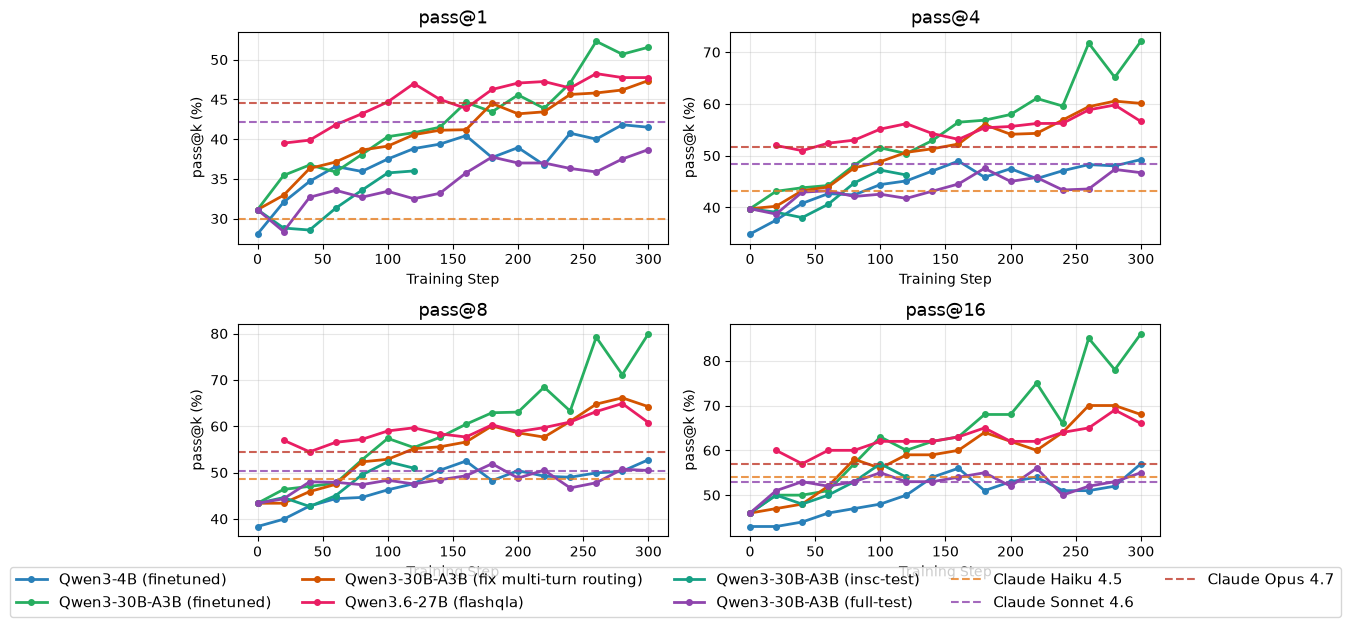

Saved to ./pass_at_k_4b_30b_vs_claude.png


In [5]:
# ── 4. Plot ──────────────────────────────────────────────────────────

claude_colors = {
    "Claude Haiku 4.5": "#E67E22",
    "Claude Sonnet 4.6": "#8E44AD",
    "Claude Opus 4.7": "#C0392B",
}

n_plots = len(PASS_K_VALUES)
cols = 2
rows = (n_plots + 1) // 2

fig, axes = plt.subplots(rows, cols, figsize=(10, 3 * rows), sharex=False, sharey=False)

# Legend handles
legend_handles = []
for c in curves.values():
    legend_handles.append(Line2D([0], [0], color=c["color"], marker="o", markersize=4, linewidth=2, label=c["display"]))
for display_name in claude_scores:
    legend_handles.append(
        Line2D(
            [0], [0], color=claude_colors[display_name], linestyle="--", linewidth=1.5, alpha=0.8, label=display_name
        )
    )

for idx, k in enumerate(PASS_K_VALUES):
    ax = axes[idx // cols][idx % cols]
    for c in curves.values():
        ax.plot(
            c["steps"],
            [v * 100 for v in c[f"pass@{k}"]],
            marker="o",
            markersize=4,
            linewidth=2,
            color=c["color"],
        )
    for display_name, pak in claude_scores.items():
        score = pak.get(k, 0) * 100
        ax.axhline(
            y=score,
            linestyle="--",
            linewidth=1.5,
            color=claude_colors.get(display_name, "gray"),
            alpha=0.8,
        )
    ax.set_title(f"pass@{k}", fontsize=13)
    ax.set_xlabel("Training Step")
    ax.set_ylabel("pass@k (%)")
    ax.grid(True, alpha=0.3)

# Single shared legend at the bottom
ncol = max(2, len(legend_handles) // 2 + len(legend_handles) % 2)
fig.legend(handles=legend_handles, loc="lower center", ncol=ncol, fontsize=11, bbox_to_anchor=(0.5, -0.05))

fig.tight_layout()
out_path = "./pass_at_k_4b_30b_vs_claude.png"
plt.savefig(out_path, dpi=150, bbox_inches="tight")
plt.savefig("./pass_at_k_4b_30b_vs_claude.pdf", bbox_inches="tight")
plt.show()
print(f"Saved to {out_path}")